# Portfolio Optimization & Machine Learning Return Forecasting
This notebook focuses purely on the Data Science and Quantitative Finance aspects of the project. We will fetch historical data, run a Markowitz mean-variance optimization, and finally build a Random Forest model to forecast future returns based on momentum and volatility features.


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics
sns.set_theme(style="darkgrid")


## 1. Data Fetching
We define our stock universe across various sectors and download historical adjusted close prices.


In [2]:
STOCK_SECTORS = {
    "Technology": ["AAPL", "MSFT", "NVDA"],
    "Finance": ["JPM", "BAC", "GS"],
    "Energy": ["XOM", "CVX", "COP"],
    "Consumer Staples": ["PG", "KO", "WMT"],
    "Healthcare": ["JNJ", "UNH", "PFE"],
    "Industrial": ["CAT", "BA", "MMM"],
}
ALL_TICKERS = [t for tickers in STOCK_SECTORS.values() for t in tickers]

print(f"Fetching data for {len(ALL_TICKERS)} stocks...")
data = yf.download(ALL_TICKERS, start="2019-04-01", end="2025-03-31", auto_adjust=False, progress=False)
prices = data["Adj Close"]

if hasattr(prices.columns, "get_level_values"):
    prices.columns = prices.columns.get_level_values(0)

monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()
monthly_returns.head()


Fetching data for 18 stocks...


Ticker,AAPL,BA,BAC,CAT,COP,CVX,GS,JNJ,JPM,KO,MMM,MSFT,NVDA,PFE,PG,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,
2019-05-31,-0.124213,-0.090332,-0.130150,-0.140654,-0.061254,-0.042394,-0.109788,-0.064820,-0.086945,0.001427,-0.149824,-0.049481,-0.250748,0.031476,-0.033527,0.037457,-0.008373,-0.108356
2019-06-30,0.130519,0.065572,0.096116,0.137551,0.034600,0.093017,0.121157,0.061990,0.055115,0.044524,0.085070,0.083118,0.212388,0.043353,0.065494,0.013609,0.089216,0.082803
2019-07-31,0.076394,-0.062718,0.057931,-0.026465,-0.026553,-0.010688,0.075904,-0.065049,0.044913,0.033582,0.007961,0.017244,0.027339,-0.103416,0.083488,0.020491,-0.000996,-0.029623
2019-08-31,-0.016461,0.073808,-0.103325,-0.096225,-0.116791,-0.033952,-0.067870,-0.006897,-0.052931,0.045791,-0.065935,0.015036,-0.006189,-0.076143,0.018553,-0.060279,0.040247,-0.067624
2019-09-30,0.072961,0.044989,0.067331,0.061428,0.091989,0.007475,0.016282,0.007946,0.071272,-0.003670,0.016572,0.008487,0.039162,0.010689,0.034517,-0.066902,0.038684,0.031104


## 2. Portfolio Optimization (Markowitz Mean-Variance)
We will optimize the portfolio to maximize returns while penalizing variance (risk). We also add constraints so no single stock exceeds 15% of the portfolio.


/var/folders/1c/m4hy22md40d54nvxbjn6_55w0000gn/T/ipykernel_82951/3936246767.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weights_df, x="Ticker", y="Weight", palette="viridis")


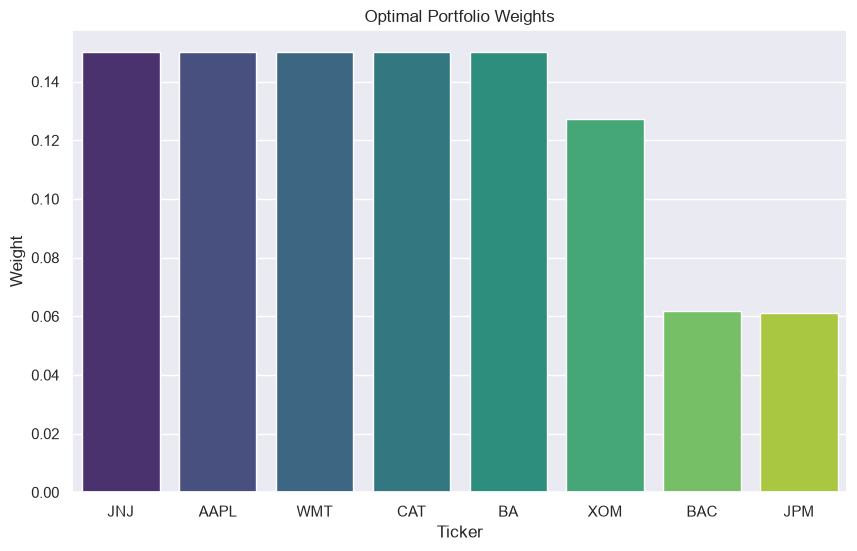

In [3]:
# Parameters
risk_aversion = 3  # lambda
max_weight = 0.15

mean_returns = monthly_returns.mean().values
cov_matrix = monthly_returns.cov().values
cov_matrix = (cov_matrix + cov_matrix.T) / 2  # Symmetrize

n_assets = len(ALL_TICKERS)
w = cp.Variable(n_assets)

# Constraints: fully invested, long-only, max position size
constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]

# Objective
objective = cp.Maximize(mean_returns @ w - 0.5 * risk_aversion * cp.quad_form(w, cp.psd_wrap(cov_matrix)))

# Solve
problem = cp.Problem(objective, constraints)
problem.solve()

optimal_weights = np.maximum(w.value, 0)
optimal_weights /= optimal_weights.sum()

weights_df = pd.DataFrame({"Ticker": ALL_TICKERS, "Weight": optimal_weights})
weights_df = weights_df[weights_df["Weight"] > 0.01].sort_values("Weight", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=weights_df, x="Ticker", y="Weight", palette="viridis")
plt.title("Optimal Portfolio Weights")
plt.ylabel("Weight")
plt.show()


## 3. Machine Learning: Return Forecasting
Here, we build a Random Forest Regressor to predict next month's returns. We engineer features based on historical momentum and volatility.


In [4]:
# 3.1 Feature Engineering
market_returns = monthly_returns.mean(axis=1)
ml_data = []

for ticker in ALL_TICKERS:
    ret = monthly_returns[ticker]
    features = pd.DataFrame(index=ret.index)
    features["Ticker"] = ticker
    features["Lag_1M"] = ret.shift(1)
    features["Momentum_3M"] = ret.rolling(3).mean().shift(1)
    features["Momentum_6M"] = ret.rolling(6).mean().shift(1)
    features["Volatility_3M"] = ret.rolling(3).std().shift(1)
    features["Volatility_6M"] = ret.rolling(6).std().shift(1)
    features["Market_Return_1M"] = market_returns.shift(1)
    features["Target_Return_1M"] = ret
    ml_data.append(features)

dataset = pd.concat(ml_data).dropna()
print(f"Dataset shape: {dataset.shape}")
dataset.head()


Dataset shape: (1170, 8)


,Ticker,Lag_1M,Momentum_3M,Momentum_6M,Volatility_3M,Volatility_6M,Market_Return_1M,Target_Return_1M
Date,,,,,,,,
2019-11-30,AAPL,0.110684,0.055728,0.041648,0.065301,0.095644,0.034650,0.077554
2019-12-31,AAPL,0.077554,0.087067,0.075275,0.020582,0.050464,0.046111,0.098784
2020-01-31,AAPL,0.098784,0.095674,0.069986,0.016783,0.044869,0.037087,0.054010
2020-02-29,AAPL,0.054010,0.076783,0.066255,0.022397,0.045159,-0.030284,-0.114702
2020-03-31,AAPL,-0.114702,0.012697,0.049882,0.112579,0.083056,-0.089372,-0.069761


In [5]:
# 3.2 Walk-Forward Train/Test Split
# We train on data up to 2022, and test on 2023-present to avoid data leakage
train_mask = dataset.index <= "2022-12-31"
test_mask = dataset.index > "2022-12-31"

feature_cols = ["Lag_1M", "Momentum_3M", "Momentum_6M", "Volatility_3M", "Volatility_6M", "Market_Return_1M"]

X_train = dataset.loc[train_mask, feature_cols]
y_train = dataset.loc[train_mask, "Target_Return_1M"]
X_test = dataset.loc[test_mask, feature_cols]
y_test = dataset.loc[test_mask, "Target_Return_1M"]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 684
Testing samples: 486


In [6]:
# 3.3 Train Random Forest
model = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=8, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
directional_accuracy = (np.sign(y_pred) == np.sign(y_test)).mean()

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")


MAE: 0.0588
RMSE: 0.0784
Directional Accuracy: 52.26%


/var/folders/1c/m4hy22md40d54nvxbjn6_55w0000gn/T/ipykernel_82951/1782768176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="mako")


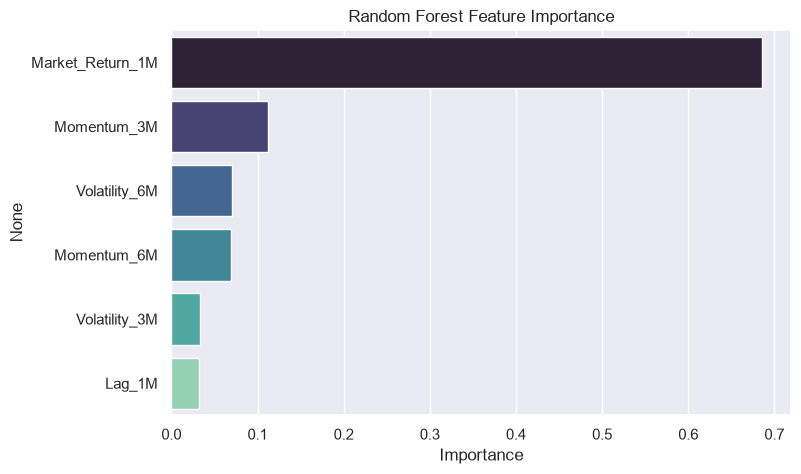

In [7]:
# 3.4 Feature Importance
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, palette="mako")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()
